# Session Analysis

## Key Findings

**Question answered:** Do users convert in a single visit, or do they need multiple sessions — and does browsing depth predict intent?

**Finding 1 — Session depth predicts conversion (33x gap)**
Users who view 15+ items in a session convert to cart at **44.7%**, vs. **1.4%** for users who view only 1 item. This is the strongest signal in the dataset: engagement depth is the primary driver of conversion, not checkout friction.

**Finding 2 — 54.6% of purchasers needed more than one session**
The median purchaser took **2 sessions** before buying. Over half of converters came back for a second visit, suggesting a consideration journey rather than an impulse purchase dynamic. The implication is re-engagement investment (email capture, retargeting) over cart/checkout optimization.

**Next notebook:** `user_segmentation.ipynb` — rule-based behavioral segmentation into four user types (Decisive Buyers, Researchers, Cart Abandoners, Browsers).

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/events_enriched.csv', parse_dates=['timestamp'], date_format= 'mixed')
df['timestamp'] = pd.to_datetime(df['timestamp'].astype('int64'), unit='ms')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns}')


Shape: (2756101, 8)
Columns: Index(['itemid', 'categoryid', 'parentid', 'available', 'timestamp',
       'visitorid', 'event', 'transactionid'],
      dtype='object')


In [3]:
df['timestamp'].head()

0   2015-06-02 05:02:12.117
1   2015-06-02 05:50:14.164
2   2015-06-02 05:13:19.827
3   2015-06-02 05:12:35.914
4   2015-06-02 05:02:17.106
Name: timestamp, dtype: datetime64[ns]

## New Session?

In [4]:
sorted_df = df.sort_values(by= ['visitorid', 'timestamp'])
sorted_df['time_since_last'] = sorted_df.groupby('visitorid')['timestamp'].diff().dt.total_seconds()/60
sorted_df['new_session'] = (sorted_df['time_since_last'] > 30) | (sorted_df['time_since_last'].isnull())
sorted_df['session_id'] = sorted_df.groupby('visitorid')['new_session'].cumsum()
sorted_df['global_session_id'] = sorted_df['visitorid'].astype(str) + '_' + sorted_df['session_id'].astype(str)

df.head(10)

,itemid,categoryid,parentid,available,timestamp,visitorid,event,transactionid
0,355908,1173.0,805.0,1.0,2015-06-02 05:02:12.117,257597,view,NaN
1,248676,1231.0,901.0,1.0,2015-06-02 05:50:14.164,992329,view,NaN
2,318965,NaN,NaN,NaN,2015-06-02 05:13:19.827,111016,view,NaN
3,253185,914.0,226.0,0.0,2015-06-02 05:12:35.914,483717,view,NaN
4,367447,491.0,679.0,0.0,2015-06-02 05:02:17.106,951259,view,NaN
5,22556,1074.0,339.0,0.0,2015-06-02 05:48:06.234,972639,view,NaN
6,443030,1098.0,897.0,1.0,2015-06-02 05:12:03.240,810725,view,NaN
7,439202,1542.0,745.0,1.0,2015-06-02 05:34:51.897,794181,view,NaN
8,428805,646.0,1606.0,0.0,2015-06-02 04:54:59.221,824915,view,NaN
9,82389,1404.0,593.0,0.0,2015-06-02 05:00:04.592,339335,view,NaN


In [ ]:
session_df = sorted_df.groupby('global_session_id').agg(
    visitorid= ('visitorid', 'first'), 
    session_duration_min = ('timestamp', lambda x: (x.max() - x.min()).total_seconds() / 60),
    events_in_session= ('event', 'count'), 
    reached_cart=('event', lambda x: (x == 'addtocart').any()),
    reached_purchase=('event', lambda x: (x == 'transaction').any()),
    categories_browsed=('parentid', 'nunique')
)

views_df = sorted_df[sorted_df['event'] == 'view']
items_viewed = views_df.groupby('global_session_id')['itemid'].nunique().rename('items_viewed')
session_df = session_df.merge(items_viewed, on='global_session_id', how='left')

In [ ]:
print(f'{session_df.head()}')
print(f'Shape: {session_df.shape}')

                   visitorid  session_duration_min  events_in_session  \
global_session_id                                                       
0_1                        0              5.462267                  3   
1000000_1            1000000              0.000000                  1   
1000001_1            1000001              0.000000                  1   
1000001_2            1000001             17.695433                  3   
1000001_3            1000001              0.000000                  1   

                   reached_cart  reached_purchase  categories_browsed  \
global_session_id                                                       
0_1                       False             False                   2   
1000000_1                 False             False                   1   
1000001_1                 False             False                   1   
1000001_2                 False             False                   1   
1000001_3                 False             False 

In [ ]:
session_df['session_number'] = session_df.groupby('visitorid').cumcount() + 1
session_df.head(10)

,visitorid,session_duration_min,events_in_session,reached_cart,reached_purchase,categories_browsed,items_viewed,session_number
global_session_id,,,,,,,,
0_1,0,5.462267,3,False,False,2,3.0,1
1000000_1,1000000,0.000000,1,False,False,1,1.0,1
1000001_1,1000001,0.000000,1,False,False,1,1.0,1
1000001_2,1000001,17.695433,3,False,False,1,3.0,2
1000001_3,1000001,0.000000,1,False,False,1,1.0,3
1000002_1,1000002,0.000000,1,False,False,0,1.0,1
1000003_1,1000003,1.889733,2,False,False,1,2.0,1
1000004_1,1000004,0.000000,1,False,False,1,1.0,1
1000005_1,1000005,0.000000,1,False,False,0,1.0,1


## Conversion by session depth

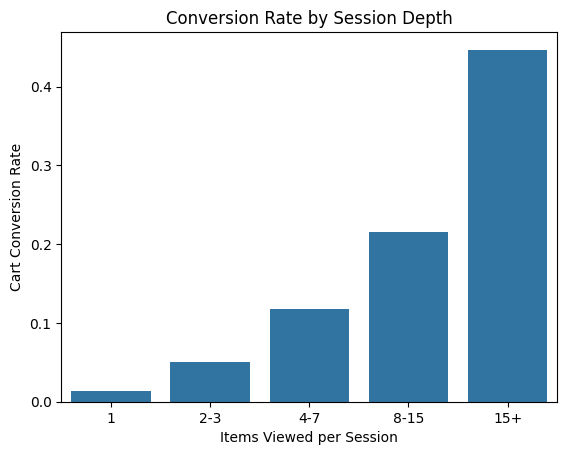

In [ ]:
session_df['items_viewed_bucket'] = pd.cut(session_df['items_viewed'], 
                                           bins = [0, 1, 3, 7, 15, 999], 
                                           labels= ['1', '2-3', '4-7', '8-15', '15+'])

conversion_by_depth = session_df.groupby('items_viewed_bucket', observed= True)['reached_cart'].mean()
sns.barplot(x= conversion_by_depth.index, y= conversion_by_depth.values)

plt.xlabel('Items Viewed per Session')
plt.ylabel('Cart Conversion Rate')
plt.title('Conversion Rate by Session Depth')
plt.show()


## Multi Session Journey

In [ ]:
user_sessions = session_df.groupby('visitorid').agg(
    total_sessions= ('session_number', 'max'), 
    purchase_made= ('reached_purchase', 'max')
)

total_sessions = user_sessions[user_sessions['purchase_made']]
user_multiple_sessions = total_sessions[(total_sessions['total_sessions'] > 1)]

print(f'The percentage of purchasers who needed more than one session {round(user_multiple_sessions.shape[0] / total_sessions.shape[0], 4)}')
print(f'Total Median: {total_sessions['total_sessions'].median()}')

The percentage of purchasers who needed more than one session 0.5461
Total Median: 2.0


In [ ]:
session_df.to_csv('data/processed/sessions.csv', index= False)

NameError: name 'session_df' is not defined